<a href="https://colab.research.google.com/github/GDVevo/ml_uni/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%9B%D0%B8%D0%BD%D0%B5%D0%B9%D0%BD%D0%B0%D1%8F_%D0%B8_%D0%BB%D0%BE%D0%B3%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B5%D0%B3%D1%80%D0%B5%D1%81%D1%81%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №5. Линейная и логистическая регрессия**

## **Линейная регрессия**


###  **Задание №1. Прогнозирование продаж автомобилей**:


   - **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
     - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
     - **Совет**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).

- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

Using Colab cache for faster access to the 'car-sales' dataset.
Manufacturer            0
Model                   0
Sales_in_thousands      0
__year_resale_value    36
Vehicle_type            0
Price_in_thousands      2
Engine_size             1
Horsepower              1
Wheelbase               1
Width                   1
Length                  1
Curb_weight             2
Fuel_capacity           1
Fuel_efficiency         3
Latest_Launch           0
Power_perf_factor       2
dtype: int64


<Axes: >

,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,0.00,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,0.000000
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639


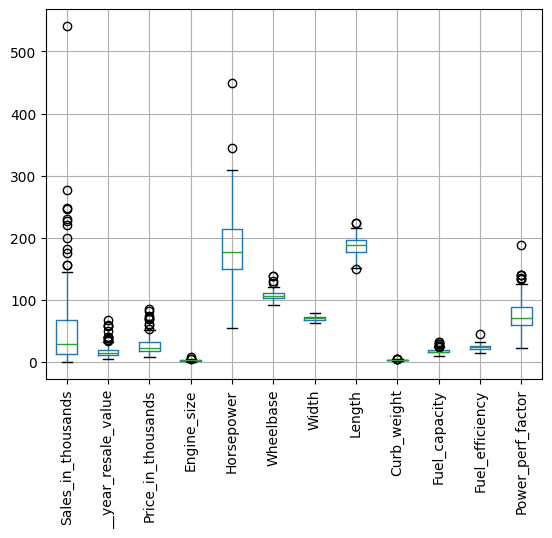

In [18]:
# Ваш код
import pandas as pd
import kagglehub
kagglehub.dataset_download("gagandeep16/car-sales")

df = pd.read_csv('/kaggle/input/car-sales/Car_sales.csv') # если вывел ошибку, запустить еще раз

print(df.isnull().sum())
display(df.boxplot(rot=90))

df.fillna(0, inplace=True)

df.head()

   - **Шаг 2**: Проведите предварительный анализ данных:
     - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
     - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
     - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

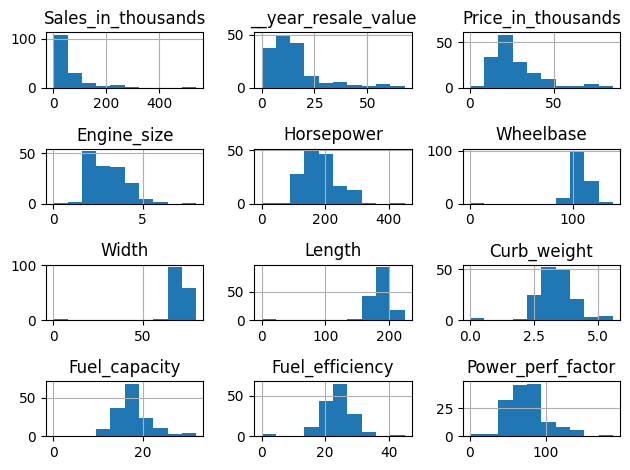

In [4]:
# Ваш код
import matplotlib.pyplot as plt

df.hist()
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")
/usr/local/lib/python3.12/dist-packages/pandas/plotting/_matplotlib/core.py:896: UserWarning: No artists with labels found to put in legend.  Note that artists whose label sta

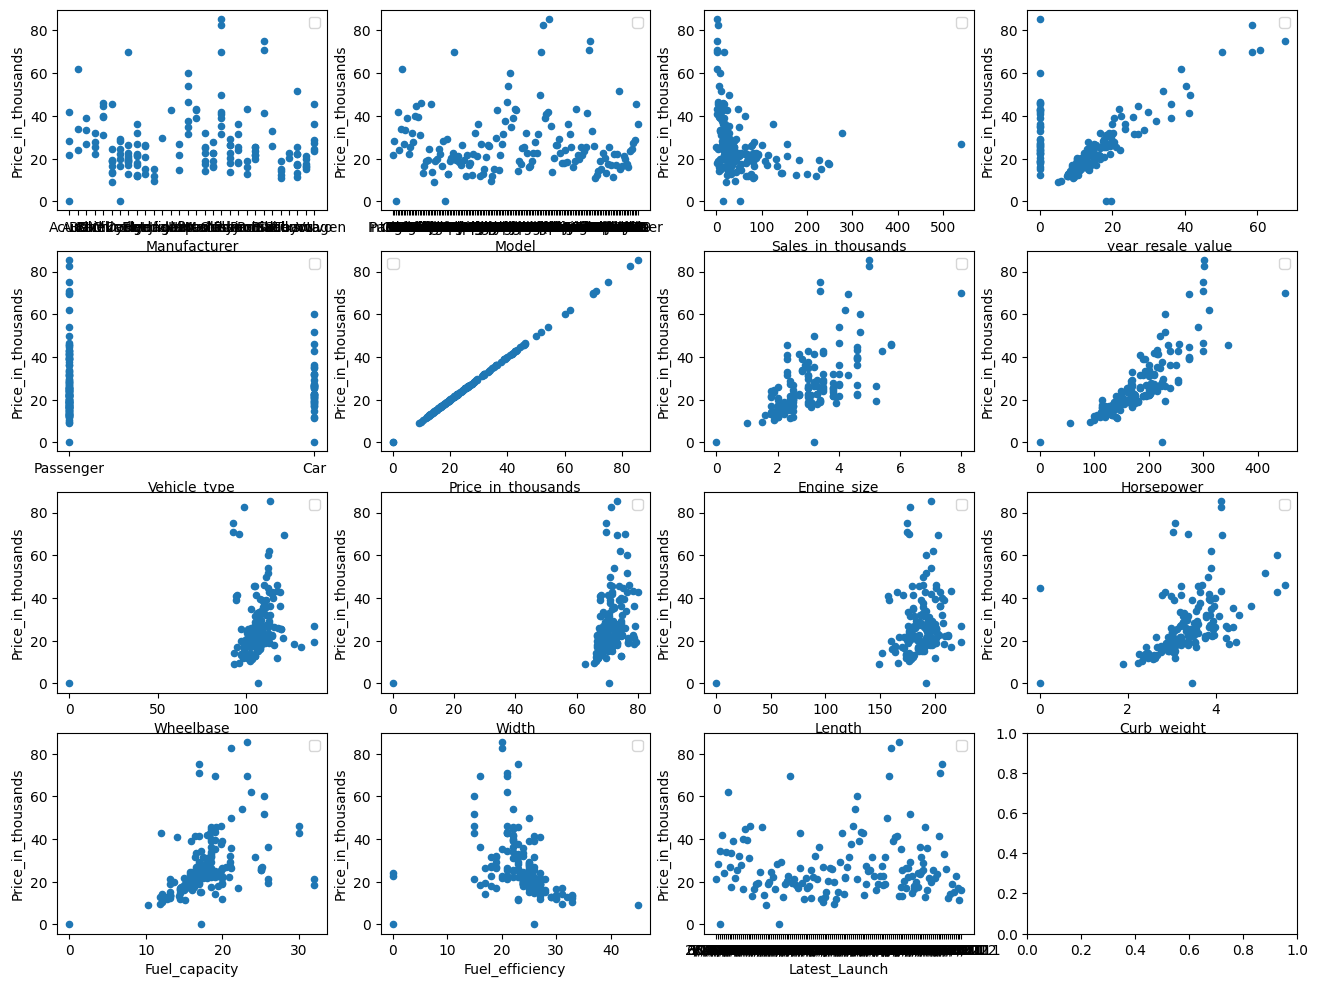

In [12]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "Price_in_thousands", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

   - **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [23]:
# Ваш код
from sklearn.model_selection import train_test_split
df2 = pd.get_dummies(df, columns=['Manufacturer', 'Latest_Launch', 'Model', 'Manufacturer', 'Vehicle_type'], drop_first=True)
X = df2.drop('Price_in_thousands', axis=1)
y = df2['Price_in_thousands']


X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=42)
display(X_train.shape, X_test.shape)
df2

(109, 354)

(48, 354)

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Manufacturer_Plymouth,Manufacturer_Pontiac,Manufacturer_Porsche,Manufacturer_Saab,Manufacturer_Saturn,Manufacturer_Subaru,Manufacturer_Toyota,Manufacturer_Volkswagen,Manufacturer_Volvo,Vehicle_type_Passenger
0,16.919,16.360,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,0.00,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,3.545,0.000,24.40,1.9,160.0,100.5,67.6,176.6,3.042,15.8,...,False,False,False,False,False,False,False,False,True,True
153,15.245,0.000,27.50,2.4,168.0,104.9,69.3,185.9,3.208,17.9,...,False,False,False,False,False,False,False,False,True,True
154,17.531,0.000,28.80,2.4,168.0,104.9,69.3,186.2,3.259,17.9,...,False,False,False,False,False,False,False,False,True,True
155,3.493,0.000,45.50,2.3,236.0,104.9,71.5,185.7,3.601,18.5,...,False,False,False,False,False,False,False,False,True,True


   - **Шаг 4**: Постройте модель линейной регрессии для предсказания цены автомобиля.
     - Используйте библиотеку `scikit-learn` для создания и обучения модели с помощью `LinearRegression`.

In [22]:
# Ваш код
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

   - **Шаг 5**: Оцените качество модели с использованием метрик MSE и R².
     - Выведите значения метрик и интерпретируйте их. Обратите внимание на то, насколько хорошо ваша модель предсказывает цены.

In [30]:
# Ваш код
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}, R2: {r2}")

MSE: 54.59903152181894, R2: 0.8095408713125207


   - **Шаг 6**: Визуализируйте результаты:
     - Постройте график зависимости предсказанных цен от фактических.

In [ ]:
# Ваш код



### **Задание №2. Влияние погодных условий на урожайность**:


   - **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
     - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture

In [ ]:
# Ваш код
import pandas as pd
import kagglehub

kagglehub.dataset_download("waqi786/climate-change-impact-on-agriculture")

df = pd.read_csv('/kaggle/input/climate-change-impact-on-agriculture/climate_change_impact_on_agriculture_2024.csv')

df.head()

Using Colab cache for faster access to the 'climate-change-impact-on-agriculture' dataset.


,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72


   - **Шаг 2**: Выполните анализ данных:
     - Постройте корреляционную матрицу для выявления зависимостей между признаками.
     - Постройте диаграммы рассеяния для ключевых признаков.
     - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.

In [ ]:
# Ваш код
import matplotlib.pyplot as plt


   - **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [ ]:
# Ваш код
from sklearn.model_selection import train_test_split

   - **Шаг 4**: Постройте модель линейной регрессии для оценки влияния температуры и уровня осадков на урожайность.
     - Используйте библиотеку `scikit-learn` для создания и обучения модели.

In [ ]:
# Ваш код
from sklearn.linear_model import LinearRegression

   - **Шаг 5**: Проведите оценку точности модели.
     - Выведите значения метрик MSE и R² и интерпретируйте их.

In [ ]:
# Ваш код
from sklearn.metrics import mean_squared_error, r2_score

   - **Шаг 6**: Визуализируйте данные и результаты модели:
     - Постройте график зависимости предсказанных значений от фактических.

In [ ]:
# Ваш код

## **Логистическая регрессия**


### **Задание №3. Классификация клиентов банка**:


   - **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
     - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [ ]:
# Ваш код
import pandas as pd
import kagglehub

kagglehub.dataset_download("henriqueyamahata/bank-marketing")

df = pd.read_csv('/kaggle/input/bank-marketing/bank-additional-full.csv', sep = ';')

df.head()

Using Colab cache for faster access to the 'bank-marketing' dataset.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


   - **Шаг 2**: Проведите анализ данных и предобработку:
     - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
     - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
     - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [ ]:
# Ваш код
from sklearn.preprocessing import StandardScaler # вместо onehot используем get_dummies

   - **Шаг 3**: Разделите данные на обучающую и тестовую выборки.


In [ ]:
# Ваш код
from sklearn.model_selection import train_test_split

   - **Шаг 4**: Постройте модель логистической регрессии для предсказания вероятности открытия депозитного счета клиентом.
     - Используйте библиотеку `scikit-learn` для создания и обучения модели с помощью `LogisticRegression`.

In [ ]:
# Ваш код
from sklearn.linear_model import LogisticRegression

   - **Шаг 5**: Оцените качество модели с использованием метрик точности, полноты и F1-меры.
     - Выведите значения метрик и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
    - Постройте матрицу ошибок с помощью `confusion_matrix` и визуализируйте ее с помощью `seaborn.heatmap`.

In [ ]:
# Ваш код
from sklearn.metrics import precision_score, f1_score, recall_score, confusion_matrix
import seaborn as sns



   

   
   

   

   
   - **Шаг 6**: Визуализируйте ROC-кривую и вычислите AUC для оценки модели.
     - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчета.

In [ ]:
# Ваш код
from sklearn.metrics import roc_curve, auc